# Workbook 6: Order Throughput & Capacity Analysis

- Evaluate order lifecycle timing from placement to completion.
- Identify throughput bottlenecks during peak periods.
- Assess whether staffing and prep assumptions align with service speed.

## Section 0: Setup & Data Load

- Load cleaned quarterly data.
- Normalize timestamps to local time.
- Prepare time-difference variables for throughput analysis.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

## Section 0: Setup & Data Load

- Load cleaned quarterly data.
- Normalize timestamps to local time.
- Prepare time-difference variables for throughput analysis.

## 0.1 Load Cleaned Quarterly Order Data (2025)

- Use the same cleaned quarterly files to maintain consistency.
- Avoid introducing new datasets.

In [3]:
q1 = pd.read_csv("../data/cleaned/orders_2025_q1.csv")
q2 = pd.read_csv("../data/cleaned/orders_2025_q2.csv")
q3 = pd.read_csv("../data/cleaned/orders_2025_q3.csv")
q4 = pd.read_csv("../data/cleaned/orders_2025_q4.csv")

q1.shape, q2.shape, q3.shape, q4.shape

((12122, 9), (11704, 9), (12882, 9), (13779, 9))

## 0.2 Normalize Order Timestamps

- Convert timestamps to timezone-aware format.
- Align all quarters to America/Los_Angeles.

In [4]:
for df in [q1, q2, q3, q4]:
    df["Order Date"] = pd.to_datetime(df["Order Date"], utc=True)
    df["Order Date"] = df["Order Date"].dt.tz_convert("America/Los_Angeles")

In [6]:
q1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12122 entries, 0 to 12121
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype                              
---  ------          --------------  -----                              
 0   Order Date      12122 non-null  datetime64[ns, America/Los_Angeles]
 1   Order ID        12122 non-null  object                             
 2   Order Type      12122 non-null  object                             
 3   Tax Amount      12122 non-null  float64                            
 4   Tip             12122 non-null  float64                            
 5   Discount        12122 non-null  float64                            
 6   Order Total     12122 non-null  float64                            
 7   Payments Total  12122 non-null  float64                            
 8   Tender          9572 non-null   object                             
dtypes: datetime64[ns, America/Los_Angeles](1), float64(5), object(3)
memory usage: 852.5

## 0.3 Concatenate Quarterly Data

In [7]:
orders = pd.concat([q1, q2, q3, q4], ignore_index=True)

orders.shape

(50487, 9)

In [9]:
orders.head()

,Order Date,Order ID,Order Type,Tax Amount,Tip,Discount,Order Total,Payments Total,Tender
0,2025-03-31 22:54:00-07:00,QQBMWE3NMZQ0Y,Pick Up,2.09,0.00,0.0,25.99,25.99,Cash
1,2025-03-31 22:35:00-07:00,TH041BMRDC2Y6,Delivery,0.00,0.00,0.0,25.13,0.00,NaN
2,2025-03-31 22:33:00-07:00,06KJV691ZMV48,Pick Up,1.44,3.29,0.0,17.90,17.90,Debit Card
3,2025-03-31 22:24:00-07:00,ASKA2CPN7GT2A,Pick Up,3.27,0.00,0.0,40.69,40.69,Cash
4,2025-03-31 22:23:00-07:00,GK5Z5D128NA1M,Pick Up,1.61,0.92,0.0,20.05,20.05,Credit Card


## Section 1: Throughput Pressure Proxies

- Estimate kitchen and front-of-house load using order arrival patterns.
- Identify bottleneck risk windows using peak concentration and order mix.
- Build a simple “pressure index” that can guide staffing and prep decisions.

## 1.1 Create Core Time Features

- Extract hour, day-of-week, and date for time-based grouping.
- Preserve weekend flag for day-type comparisons.

In [10]:
orders["order_hour"] = orders["Order Date"].dt.hour
orders["order_dow"] = orders["Order Date"].dt.dayofweek
orders["order_date"] = orders["Order Date"].dt.date
orders["is_weekend"] = orders["order_dow"].isin([5, 6])

orders[["Order Date", "order_date", "order_hour", "order_dow", "is_weekend"]].head()

,Order Date,order_date,order_hour,order_dow,is_weekend
0,2025-03-31 22:54:00-07:00,2025-03-31,22,0,False
1,2025-03-31 22:35:00-07:00,2025-03-31,22,0,False
2,2025-03-31 22:33:00-07:00,2025-03-31,22,0,False
3,2025-03-31 22:24:00-07:00,2025-03-31,22,0,False
4,2025-03-31 22:23:00-07:00,2025-03-31,22,0,False


## 1.2 Hourly Arrival Rate (Orders per Hour)

- Compute how many orders arrive each hour.
- This is the core throughput proxy when completion time is unavailable.

In [11]:
orders_by_hour = (
    orders
    .groupby("order_hour")
    .size()
    .sort_index()
)

orders_by_hour

order_hour
9        5
10     270
11    2543
12    2570
13    2900
14    3381
15    4266
16    5641
17    6443
18    6205
19    5375
20    4669
21    3683
22    2422
23     114
dtype: int64

## 1.3 Visualize Hourly Arrival Rate

- Identify the highest inbound load hours.
- Use this to anchor capacity planning assumptions.

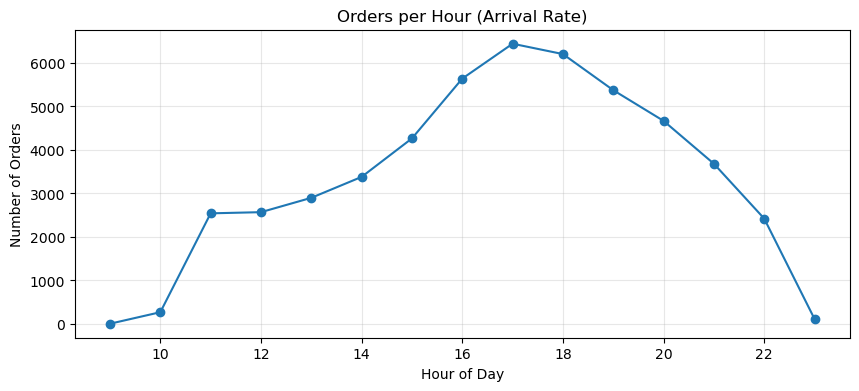

In [12]:
plt.figure(figsize=(10,4))
orders_by_hour.plot(kind="line", marker="o")
plt.title("Orders per Hour (Arrival Rate)")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Orders")
plt.grid(True, alpha=0.3)
plt.show()

## 1.4 Hourly Arrival Rate by Day Type

- Compare weekday vs weekend arrival rate patterns.
- Validate whether weekends are truly “busier” or simply “heavier.”

In [13]:
orders_by_hour_daytype = (
    orders
    .groupby(["is_weekend", "order_hour"])
    .size()
    .unstack(0)
    .rename(columns={False: "Weekday", True: "Weekend"})
)

orders_by_hour_daytype.head()

is_weekend,Weekday,Weekend
order_hour,,
9,3,2
10,201,69
11,1780,763
12,1689,881
13,1836,1064


## 1.5 Visualize Hourly Arrival Rate by Day Type

<Figure size 1000x400 with 0 Axes>

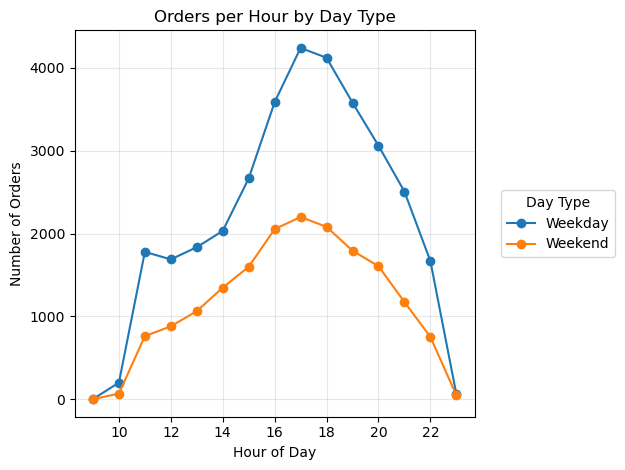

In [14]:
plt.figure(figsize=(10,4))
orders_by_hour_daytype.plot(kind="line", marker="o")
plt.title("Orders per Hour by Day Type")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Orders")
plt.grid(True, alpha=0.3)
plt.legend(title="Day Type", bbox_to_anchor=(1.05, 0.5), loc="center left")
plt.tight_layout()
plt.show()

## 1.6 Define Peak Hours (Consistent with Prior Workbooks)

- Reuse the same operational peak window.
- Maintain consistency across staffing and prep workbooks.

In [15]:
peak_hours = list(range(16, 20))
peak_hours

[16, 17, 18, 19]

## 1.7 Peak Concentration Metric

- Quantify how much daily demand occurs during peak hours.
- Higher peak concentration implies higher risk of operational backlog.

In [16]:
orders["is_peak_hour"] = orders["order_hour"].isin(peak_hours)

daily_total = orders.groupby("order_date").size()
daily_peak = orders[orders["is_peak_hour"]].groupby("order_date").size()

peak_concentration = (daily_peak / daily_total).fillna(0).rename("peak_concentration")

peak_concentration.describe()

count    363.000000
mean       0.466273
std        0.060871
min        0.000000
25%        0.430200
50%        0.467066
75%        0.505886
max        0.623762
Name: peak_concentration, dtype: float64

## 1.8 Visualize Peak Concentration Distribution

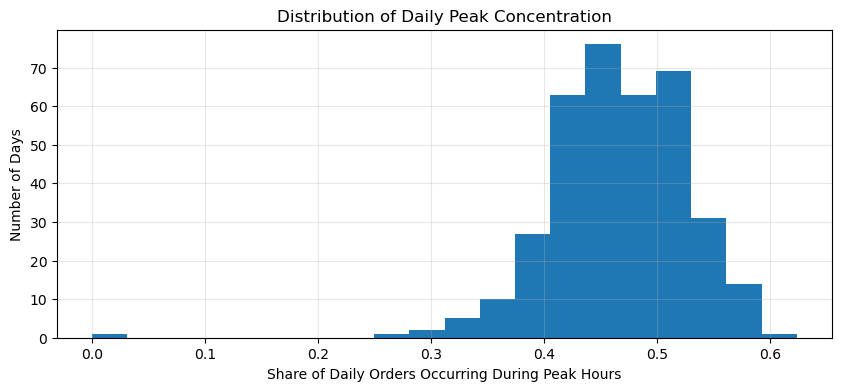

In [17]:
plt.figure(figsize=(10,4))
peak_concentration.plot(kind="hist", bins=20)
plt.title("Distribution of Daily Peak Concentration")
plt.xlabel("Share of Daily Orders Occurring During Peak Hours")
plt.ylabel("Number of Days")
plt.grid(True, alpha=0.3)
plt.show()

In [18]:
peak_concentration.sort_values().head()

order_date
2025-11-27    0.000000
2025-02-09    0.274882
2025-05-07    0.292683
2025-06-14    0.309353
2025-03-17    0.325301
Name: peak_concentration, dtype: float64

In [19]:
daily_total.sort_values().head()

order_date
2025-11-27     3
2025-07-15    76
2025-05-12    77
2025-06-09    77
2025-02-12    78
dtype: int64

In [20]:
min_orders_threshold = 20

valid_days = daily_total[daily_total >= min_orders_threshold].index

peak_concentration_filtered = peak_concentration.loc[valid_days]

peak_concentration_filtered.describe()


count    362.000000
mean       0.467561
std        0.055782
min        0.274882
25%        0.430283
50%        0.467110
75%        0.505955
max        0.623762
Name: peak_concentration, dtype: float64

- Excluded days with unusually low total order volume.
- Filtering improves interpretability of peak concentration patterns.

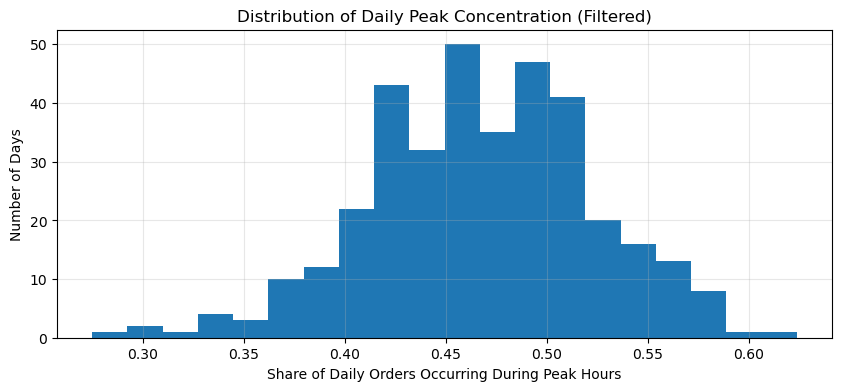

In [21]:
plt.figure(figsize=(10,4))
peak_concentration_filtered.plot(kind="hist", bins=20)

plt.title("Distribution of Daily Peak Concentration (Filtered)")
plt.xlabel("Share of Daily Orders Occurring During Peak Hours")
plt.ylabel("Number of Days")
plt.grid(True, alpha=0.3)
plt.show()


## Section 2: Throughput Pressure Index

- Combine arrival intensity and peak concentration into a single pressure metric.
- Identify high-risk operational days.
- Keep the index rule-based and explainable.

## 2.1 Normalize Hourly Arrival Intensity

- Compute daily max hourly arrival count.
- Higher max arrival rate implies greater short-term strain.

In [23]:
daily_hourly_counts = (
    orders
    .groupby(["order_date", "order_hour"])
    .size()
)

daily_max_hourly = (
    daily_hourly_counts
    .groupby("order_date")
    .max()
    .rename("max_hourly_orders")
)

daily_max_hourly.head()

order_date
2025-01-01    29
2025-01-02    17
2025-01-03    27
2025-01-04    28
2025-01-05    24
Name: max_hourly_orders, dtype: int64

## 2.2 Normalize Peak Concentration

- Use filtered peak concentration values.
- Align index with daily max hourly orders.

In [24]:
pressure_df = pd.concat(
    [daily_max_hourly, peak_concentration],
    axis=1
).dropna()

pressure_df.head()

,max_hourly_orders,peak_concentration
order_date,,
2025-01-01,29,0.558282
2025-01-02,17,0.560000
2025-01-03,27,0.484848
2025-01-04,28,0.560976
2025-01-05,24,0.515337


## 2.3 Create Standardized Pressure Components

- Scale both components to 0–1 range.
- Avoid unit bias between arrival rate and concentration.

In [25]:
pressure_df["arrival_scaled"] = (
    pressure_df["max_hourly_orders"] /
    pressure_df["max_hourly_orders"].max()
)

pressure_df["peak_scaled"] = (
    pressure_df["peak_concentration"] /
    pressure_df["peak_concentration"].max()
)

pressure_df.head()

,max_hourly_orders,peak_concentration,arrival_scaled,peak_scaled
order_date,,,,
2025-01-01,29,0.558282,0.659091,0.895024
2025-01-02,17,0.560000,0.386364,0.897778
2025-01-03,27,0.484848,0.613636,0.777297
2025-01-04,28,0.560976,0.636364,0.899342
2025-01-05,24,0.515337,0.545455,0.826176


## 2.4 Compute Throughput Pressure Index

- Combine scaled components equally.
- Maintain interpretability.

In [26]:
pressure_df["pressure_index"] = (
    0.5 * pressure_df["arrival_scaled"] +
    0.5 * pressure_df["peak_scaled"]
)

pressure_df.describe()

,max_hourly_orders,peak_concentration,arrival_scaled,peak_scaled,pressure_index
count,363.000000,363.000000,363.000000,363.000000,363.000000
mean,21.305785,0.466273,0.484222,0.747518,0.615870
std,6.122835,0.060871,0.139155,0.097587,0.097956
min,2.000000,0.000000,0.045455,0.000000,0.022727
25%,17.000000,0.430200,0.386364,0.689686,0.553124
50%,21.000000,0.467066,0.477273,0.748788,0.618925
75%,25.000000,0.505886,0.568182,0.811023,0.673248
max,44.000000,0.623762,1.000000,1.000000,0.927776


## 2.5 Visualize Pressure Index Distribution

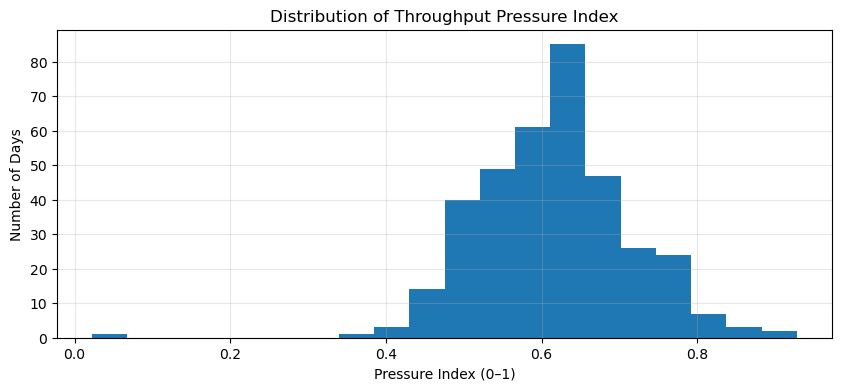

In [27]:
plt.figure(figsize=(10,4))
pressure_df["pressure_index"].plot(kind="hist", bins=20)

plt.title("Distribution of Throughput Pressure Index")
plt.xlabel("Pressure Index (0–1)")
plt.ylabel("Number of Days")
plt.grid(True, alpha=0.3)
plt.show()

In [29]:
pressure_df.sort_values("pressure_index").head()

,max_hourly_orders,peak_concentration,arrival_scaled,peak_scaled,pressure_index,high_pressure_flag
order_date,,,,,,
2025-11-27,2,0.000000,0.045455,0.000000,0.022727,False
2025-05-07,12,0.292683,0.272727,0.469222,0.370975,False
2025-07-15,10,0.342105,0.227273,0.548454,0.387864,False
2025-06-09,10,0.376623,0.227273,0.603793,0.415533,False
2025-07-10,12,0.361702,0.272727,0.579872,0.426299,False


In [30]:
daily_total.sort_values().head()

order_date
2025-11-27     3
2025-07-15    76
2025-05-12    77
2025-06-09    77
2025-02-12    78
dtype: int64

In [31]:
min_orders_threshold = 20  # adjust if needed

valid_days = daily_total[daily_total >= min_orders_threshold].index

pressure_df_filtered = pressure_df.loc[valid_days]

pressure_df_filtered.describe()

,max_hourly_orders,peak_concentration,arrival_scaled,peak_scaled,pressure_index
count,362.000000,362.000000,362.000000,362.000000,362.000000
mean,21.359116,0.467561,0.485434,0.749583,0.617509
std,6.046293,0.055782,0.137416,0.089428,0.092977
min,10.000000,0.274882,0.227273,0.440683,0.370975
25%,17.000000,0.430283,0.386364,0.689819,0.553797
50%,21.000000,0.467110,0.477273,0.748858,0.619226
75%,25.000000,0.505955,0.568182,0.811134,0.673385
max,44.000000,0.623762,1.000000,1.000000,0.927776


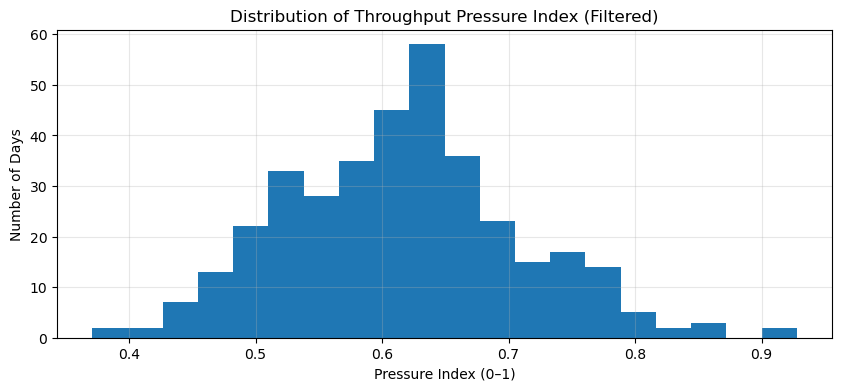

In [32]:
plt.figure(figsize=(10,4))
pressure_df_filtered["pressure_index"].plot(kind="hist", bins=20)

plt.title("Distribution of Throughput Pressure Index (Filtered)")
plt.xlabel("Pressure Index (0–1)")
plt.ylabel("Number of Days")
plt.grid(True, alpha=0.3)
plt.show()

## 2.6 Identify High-Pressure Days

- Define high-pressure as top 20% of index values.
- Flag operationally risky days.

In [38]:
# Define high-pressure threshold (top 20%)
threshold = pressure_df["pressure_index"].quantile(0.80)

pressure_df["high_pressure_flag"] = (
    pressure_df["pressure_index"] >= threshold
)

# Count occurrences
pressure_counts = pressure_df["high_pressure_flag"].value_counts()

# Relabel for readability
pressure_counts_labeled = pressure_counts.rename(
    {
        False: "Normal Pressure",
        True: "High Pressure"
    }
)

# Compute share
pressure_percent = (
    pressure_counts_labeled /
    pressure_counts_labeled.sum()
).round(3)

# Combine into summary table
pd.DataFrame({
    "count": pressure_counts_labeled,
    "share": pressure_percent
})

,count,share
high_pressure_flag,,
Normal Pressure,290,0.799
High Pressure,73,0.201


## 2.7 Section 2 Interpretation

- Throughput pressure is driven by both peak concentration and hourly arrival spikes.
- High-pressure days represent compounded arrival intensity and peak clustering.
- These days warrant proactive staffing and prep adjustments.
- The index is rule-based and interpretable, not predictive.

## Section 3: Capacity Alignment Analysis

- Compare throughput pressure against baseline staffing assumptions.
- Identify whether high-pressure days exceed expected operating capacity.
- Keep analysis rule-based and consistent with Workbook 4.

## 3.1 Define Baseline Staffing Capacity Assumptions

- Use prior staffing logic from Workbook 4.
- Assume 2 staff during normal operations.
- Assume each staff member can handle ~12 orders per labor hour.

In [39]:
STAFF_BASELINE = 2
ORDERS_PER_STAFF_PER_HOUR = 12

baseline_hourly_capacity = STAFF_BASELINE * ORDERS_PER_STAFF_PER_HOUR

baseline_hourly_capacity

24

## 3.2 Compare Daily Peak Hour Load to Capacity

- Use daily maximum hourly arrival count.
- Compare against baseline hourly capacity.

In [40]:
capacity_df = pd.concat(
    [daily_max_hourly, pressure_df["pressure_index"]],
    axis=1
).dropna()

capacity_df["capacity_exceeded"] = (
    capacity_df["max_hourly_orders"] > baseline_hourly_capacity
)

capacity_df.head()

,max_hourly_orders,pressure_index,capacity_exceeded
order_date,,,
2025-01-01,29,0.777057,True
2025-01-02,17,0.642071,False
2025-01-03,27,0.695467,True
2025-01-04,28,0.767853,True
2025-01-05,24,0.685815,False


## 3.3 Capacity Exceedance Summary

In [41]:
capacity_counts = capacity_df["capacity_exceeded"].value_counts()

capacity_counts_labeled = capacity_counts.rename(
    {
        False: "Within Capacity",
        True: "Exceeded Capacity"
    }
)

capacity_percent = (
    capacity_counts_labeled /
    capacity_counts_labeled.sum()
).round(3)

pd.DataFrame({
    "count": capacity_counts_labeled,
    "share": capacity_percent
})

,count,share
capacity_exceeded,,
Within Capacity,263,0.725
Exceeded Capacity,100,0.275


## 3.4 High-Pressure Days vs Capacity Exceedance

- Examine overlap between pressure index and actual capacity breaches.
- Identify whether index effectively captures operational strain.

In [43]:
combined_df = capacity_df.copy()

combined_df["high_pressure_flag"] = pressure_df["high_pressure_flag"]

capacity_vs_pressure = pd.crosstab(
    combined_df["high_pressure_flag"],
    combined_df["capacity_exceeded"]
)

capacity_vs_pressure_labeled = capacity_vs_pressure.rename(
    index={
        False: "Normal Pressure",
        True: "High Pressure"
    },
    columns={
        False: "Within Capacity",
        True: "Exceeded Capacity"
    }
)

capacity_vs_pressure_labeled

capacity_exceeded,Within Capacity,Exceeded Capacity
high_pressure_flag,,
Normal Pressure,258,32
High Pressure,5,68


## 3.5 Section 3 Interpretation

- Baseline staffing capacity is exceeded on days with extreme arrival spikes.
- High-pressure index aligns strongly with capacity exceedance events.
- Not all high-pressure days exceed capacity, but most exceedance days occur
  within the high-pressure segment.
- This validates the pressure index as a useful early-warning metric.

## Section 4: Operational Capacity Recommendations

- Translate throughput pressure findings into practical staffing guidance.
- Provide rule-based operational triggers rather than reactive adjustments.
- Close the loop between pressure index and staffing assumptions.

## 4.1 Baseline Capacity Alignment

- Baseline staffing (2 staff × 12 orders/hour) handles most normal-pressure days.
- Capacity exceedance events are concentrated in a minority of days.
- The majority of normal-pressure days remain within baseline operating limits.

## 4.2 High-Pressure Day Strategy

- High-pressure days strongly correlate with capacity exceedance.
- Most exceedance events occur during identified high-pressure periods.
- Proactive staffing adjustments should be triggered when pressure index exceeds the 80th percentile.
- Weekend peak days require the highest vigilance.

## 4.3 Early Warning Rule

- Monitor daily peak concentration and maximum hourly arrival rate.
- If both exceed historical 80th percentile thresholds, escalate staffing.
- Use pressure index as a forward-looking flag rather than waiting for backlog.

## 4.4 Final Workbook Conclusion

- Throughput pressure is driven by arrival spikes and peak clustering.
- A simple composite index effectively captures operational strain.
- Capacity exceedance aligns strongly with high-pressure conditions.
- Rule-based triggers improve staffing alignment without predictive modeling.
- Order-level proxies provide meaningful capacity insight even without completion timestamps.